In [ ]:
import pandas as pd
import importlib

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Estrategia import EstrategiaMLEquiponderada, EstrategiaMLMinVarAlphaTilt, EstrategiaMLMonteCarlo
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

# EURO STOXX 50

In [2]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers}")

# tickers = [
#     "ADS.DE",    # Adidas
#     "ADYEN.AS",  # Adyen
#     "AD.AS",     # Ahold Delhaize
#     "AI.PA",     # Air Liquide
#     "AIR.PA",    # Airbus
#     "ALV.DE",    # Allianz
#     "ABI.BR",    # Anheuser-Busch InBev
#     "ASML.AS",   # ASML
#     "CS.PA",     # AXA
#     "BBVA.MC",   # BBVA
#     "SAN.MC",    # Santander
#     "BAS.DE",    # BASF
#     "BAYN.DE",   # Bayer
#     "BMW.DE",    # BMW
#     "BNP.PA",    # BNP Paribas
#     "CRH.L",     # CRH
#     "MBG.DE",    # Mercedes-Benz
#     "BN.PA",     # Danone
#     "DB1.DE",    # Deutsche Börse
#     "DHL.DE",    # Deutsche Post
#     "DTE.DE",    # Deutsche Telekom
#     "ENEL.MI",   # Enel
#     "ENI.MI",    # ENI
#     "EL.PA",     # EssilorLuxottica
#     "FLTR.L",    # Flutter Entertainment
#     "RMS.PA",    # Hermès
#     "IBE.MC",    # Iberdrola
#     "ITX.MC",    # Inditex
#     "IFX.DE",    # Infineon
#     "INGA.AS",   # ING Groep
#     "ISP.MI",    # Intesa Sanpaolo
#     "KER.PA",    # Kering
#     "KNEBV.HE",  # Kone
#     "OR.PA",     # L'Oréal
#     "LIN.DE",    # Linde
#     "MC.PA",     # LVMH
#     "MUV2.DE",   # Münchener Rück
#     "RI.PA",     # Pernod Ricard
#     "PHIA.AS",   # Philips
#     "PRX.AS",    # Prosus
#     "SAF.PA",    # Safran
#     "SAN.PA",    # Sanofi
#     "SAP.DE",    # SAP
#     "SU.PA",     # Schneider Electric
#     "SIE.DE",    # Siemens
#     "STLAM.MI",  # Stellantis (no STLA.MI)
#     "TTE.PA",    # TotalEnergies
#     "DG.PA",     # Vinci
#     "VOW3.DE",   # Volkswagen Pref
#     "VNA.DE",    # Vonovia
# ]

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA', 'ALV.DE', 'ABI.BR', 'ARGX.BR', 'ASML.AS', 'CS.PA', 'BAS.DE', 'BAYN.DE', 'BBVA.MC', 'SAN.MC', 'BMW.DE', 'BNP.PA', 'BN.PA', 'DBK.DE', 'DB1.DE', 'DHL.DE', 'DTE.DE', 'ENEL.MI', 'ENI.MI', 'EL.PA', 'RACE.MI', 'RMS.PA', 'IBE.MC', 'ITX.MC', 'IFX.DE', 'INGA.AS', 'ISP.MI', 'OR.PA', 'MC.PA', 'MBG.DE', 'MUV2.DE', 'NDA-FI.HE', 'PRX.AS', 'RHM.DE', 'SAF.PA', 'SGO.PA', 'SAN.PA', 'SAP.DE', 'SU.PA', 'SIE.DE', 'ENR.DE', 'TTE.PA', 'DG.PA', 'UCG.MI', 'VOW.DE', 'WKL.AS']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_32268\4012662861.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


## RandomForest + EstrategiaMLMonteCarlo

[*********************100%***********************]  54 of 54 completed
[*********************100%***********************]  54 of 54 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(
[*********************100%***********************]  1 of 1 completed


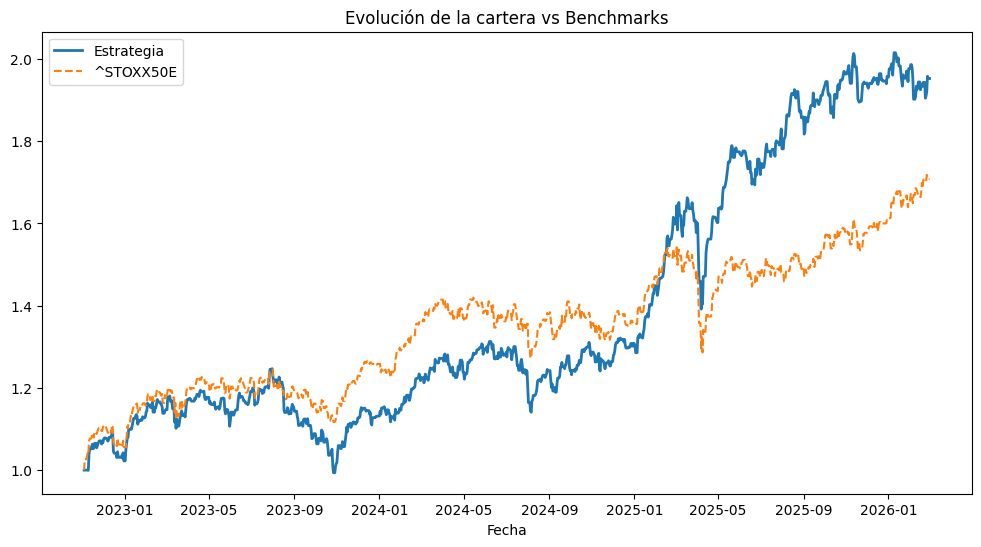

,Estrategia,^STOXX50E
Rentabilidad total,95.26%,70.84%
Rentabilidad anualizada,14.90%,11.76%
Volatilidad anualizada,14.07%,12.38%
Sharpe,1.06,0.96
Sortino,1.51,1.37
Max Drawdown,-20.30%,-16.58%
Calmar,0.73,0.71
Win rate,39.79%,36.90%
Mejor periodo,4.76%,4.26%
Peor periodo,-4.67%,-4.81%


In [ ]:
start_date = "2023-01-03"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=7, ticker_indice="^STOXX50E")
modelo = RandomForestModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLEquiponderada

In [ ]:
start_date = "2023-01-03"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="^STOXX50E")
modelo = RandomForestModel(random_state=42, n_splits=3)  # ← solo random_state, el resto lo decide el CV
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=15, umbral_salida=22)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [5]:
import yfinance as yf
from datetime import datetime

# Selecciona el ticker que quieras, por ejemplo 'ADS.DE'
ticker = 'ONSW.DE'

# Descarga los datos de hoy
hoy = datetime.today().strftime('%Y-%m-%d')
data = yf.download(ticker)

print(data)

[*********************100%***********************]  1 of 1 completed

Price        Close    High     Low    Open  Volume
Ticker     ONSW.DE ONSW.DE ONSW.DE ONSW.DE ONSW.DE
Date                                              
2026-02-13  5.0213  5.0213  5.0213  5.0213       0
2026-02-16  5.0216  5.0216  5.0216  5.0216       0
2026-02-17  5.0381  5.0381  5.0220  5.0220   19915
2026-02-18  5.0223  5.0223  5.0223  5.0223       0
2026-02-19  5.0231  5.0231  5.0231  5.0231       0
2026-02-20  5.0235  5.0235  5.0235  5.0235       0
2026-02-23  5.0238  5.0238  5.0238  5.0238       0
2026-02-24  5.0241  5.0241  5.0241  5.0241       0
2026-02-25  5.0245  5.0245  5.0245  5.0245       0
2026-02-26  5.0251  5.0253  5.0249  5.0253    3981
2026-02-27  5.0255  5.0257  5.0253  5.0257    3403
2026-03-02  5.0258  5.0261  5.0258  5.0261       0
2026-03-03  5.0262  5.0263  5.0262  5.0263       0
2026-03-04  5.0266  5.0270  5.0266  5.0267     112
2026-03-05  5.0273  5.0274  5.0266  5.0266    8455
2026-03-06  5.0276  5.0282  5.0276  5.0282    2501
2026-03-09  5.0154  5.0268  5.0

## Random Forest + EstrategiaMLMinVarAlphaTilt

[*************         28%                       ]  17 of 61 completed$STLA.MI: possibly delisted; no timezone found
[**********************70%*********              ]  43 of 61 completed$STM.MI: possibly delisted; no timezone found
[**********************72%**********             ]  44 of 61 completed$ENR.DE: possibly delisted; no price data found  (1d 2006-01-05 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1136415600, endDate = 1583017200")
[*********************100%***********************]  61 of 61 completed

3 Failed downloads:
['STLA.MI', 'STM.MI']: possibly delisted; no timezone found
['ENR.DE']: possibly delisted; no price data found  (1d 2006-01-05 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1136415600, endDate = 1583017200")
[**********            20%                       ]  12 of 61 completed$STLA.MI: possibly delisted; no timezone found
[**********************70%*********              ]  43 of 61 completed$ENR.DE

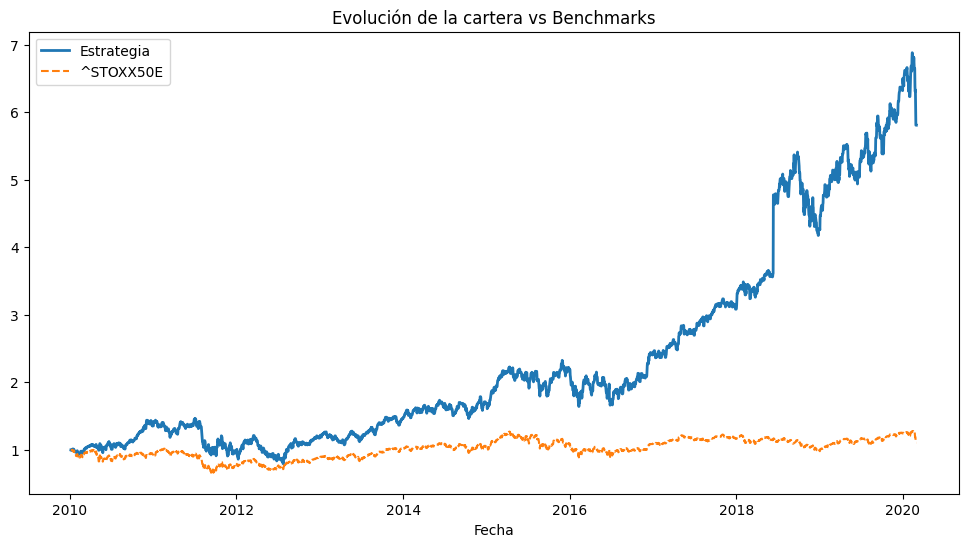

,Estrategia,^STOXX50E
Rentabilidad total,480.67%,10.53%
Rentabilidad anualizada,12.70%,0.68%
Volatilidad anualizada,24.32%,16.49%
Sharpe,0.61,0.12
Sortino,0.93,0.17
Max Drawdown,-45.83%,-34.97%
Calmar,0.28,0.02
Win rate,37.86%,35.46%
Mejor periodo,32.04%,10.35%
Peor periodo,-12.41%,-8.62%


In [6]:
modelo = RandomForestModel(n_estimators=120, max_depth=4, class_weight=None, random_state=42, positive_class_weight=5.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.2,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=3,
    nominal=10000000
)

res3 = engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLMinVarAlphaTilt

[***********           23%                       ]  14 of 61 completed$STLA.MI: possibly delisted; no timezone found
[**********************69%********               ]  42 of 61 completed$ENR.DE: possibly delisted; no price data found  (1d 2007-01-05 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1167951600, endDate = 1583017200")
[**********************70%*********              ]  43 of 61 completed$STM.MI: possibly delisted; no timezone found
[*********************100%***********************]  61 of 61 completed

3 Failed downloads:
['STLA.MI', 'STM.MI']: possibly delisted; no timezone found
['ENR.DE']: possibly delisted; no price data found  (1d 2007-01-05 00:00:00 -> 2020-03-01) (Yahoo error = "Data doesn't exist for startDate = 1167951600, endDate = 1583017200")
[********              16%                       ]  10 of 61 completed$STLA.MI: possibly delisted; no timezone found
[**********************66%*******                ]  40 of 61 completed$ENR.DE

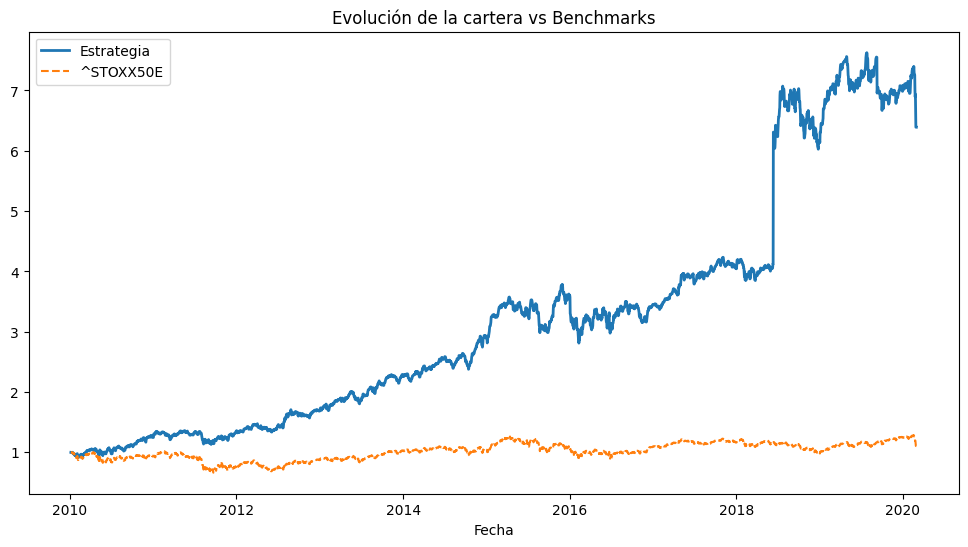

,Estrategia,^STOXX50E
Rentabilidad total,539.01%,10.53%
Rentabilidad anualizada,13.43%,0.68%
Volatilidad anualizada,19.22%,16.49%
Sharpe,0.74,0.12
Sortino,1.51,0.17
Max Drawdown,-25.76%,-34.97%
Calmar,0.52,0.02
Win rate,45.12%,35.46%
Mejor periodo,53.08%,10.35%
Peor periodo,-8.31%,-8.62%


In [7]:
modelo = XGBoostModel(n_estimators=180, max_depth=3, positive_class_weight=8.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=5.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.20,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=2,
    nominal=10000000
)

res4 = engine.print_results(bmks=["^STOXX50E"])